In [1]:
%matplotlib inline

In [27]:
import pandas as pd
import numpy as np
from scipy import stats
#from scipy.stats import entropy
#from scipy.stats import ttest_ind, chi2_contingency
import matplotlib.pyplot as plt
#import diptest


# Two Channels of Home-Court Advantage: NBA Close Games as a Testbed

## 1. Abstract

This study examines whether home court referee bias in NBA close games is reflected in betting market outcomes. Using NBA Last Two Minute (L2M) reports [AtlhawksfanaticL2M] as ground truth for referee error direction, we first replicate and extend the methodology of Pelechrinis (2023) [PelechrinisL2M] across three periods defined by crowd presence conditions: Pre-COVID (2015–2019), COVID (2020–2022), and Post-COVID (2023–2025). Referee errors are aggregated to the game level via the Net Whistle Gain (NWG) metric and linked to pre-game point spreads and cover outcomes from independent bookmakers [KaggleBetting]. The central question is whether the betting market efficiently prices home-court advantage in close games — tested through the home team cover rate across three temporal periods defined by crowd presence conditions. The COVID-19 period, during which games were played without fans, serves as a natural experiment for isolating the crowd pressure mechanism.


## 2. Introduction
Referee decisions in professional sports are not made in a vacuum. Research has documented systematic patterns in how referees make errors — favoring home teams [ErikstadJohansen2020] and higher-status players [Barrett2021]. This study examines whether these patterns are detectable not only in officiating data, but in the outcomes of betting markets as well.

### 2.1 Background

Home court bias is the most studied form of referee bias in professional sports. Crowd noise and social pressure from home fans have been linked to systematic differences in foul calls favoring the home team [ErikstadJohansen2020]. In the NBA specifically, Pelechrinis (2023) showed that this effect disappears when games are played without fans [PelechrinisL2M] — a strong indicator that the crowd, not the home team itself, is the driving factor.

The COVID-19 pandemic (seasons 2020–2022), during which NBA games were played without fans or with severely restricted attendance, provides a natural experiment within the dataset. If bias is driven by social pressure, it should diminish during this period — a prediction that is directly testable with the available data.

We extend this logic to the betting market. A full arena exerts direct social pressure on referees in real-time. The betting market reflects a different but related force — the collective expectations of a much wider audience, priced into the spread before tip-off. Referee bias is reactive; market pricing is inertial. Both are independent signals of the same structural phenomenon: the systematic overestimation of home-court advantage in high-stakes close games.

### 2.2 Related Work
Belasen et al. (2025) examine the same L2M data and find that referees make significantly fewer incorrect calls against underdogs than against favorites — suggesting that betting market status is associated with the direction of referee errors [BelasenL2M2025]. This study approaches the question from a complementary direction: rather than testing whether market expectations predict referee errors, we test whether referee errors predict betting outcomes.

### 2.3 Research Design

To examine Structural Convergence, two independent data sources are used.

**RQ1 — The Reactive Channel**: Do referee errors in NBA close games systematically favour the home team, and does this effect vary with crowd presence? The primary dataset is the NBA Last Two Minute (L2M) reports [AtlhawksfanaticL2M], which provide a unique ground truth — every referee decision in the final two minutes of close games is graded as correct or incorrect by the NBA league office. Referee errors are aggregated to the game level via the Net Whistle Gain (NWG) metric.

**RQ2 — The Inertial Channel**: Does the betting market systematically misprice home-court advantage in close games? Betting market data [KaggleBetting] provides pre-game point spreads and post-game cover outcomes set by independent bookmakers with no access to L2M grades. The home team cover rate is examined across three temporal periods defined by crowd presence conditions.

## 3. Methodology & Hypotheses

### 3.1 The Logic of Structural Convergence

Home-court advantage manifests through two independent channels — a Reactive Channel (social pressure on referees) and an Inertial Channel (collective belief in market pricing). We do not hypothesize a causal link between the two signals. Since spreads are set before the game, bookmakers cannot observe NWG at the time of pricing. Structural Convergence requires only that both signals consistently point in the same direction.

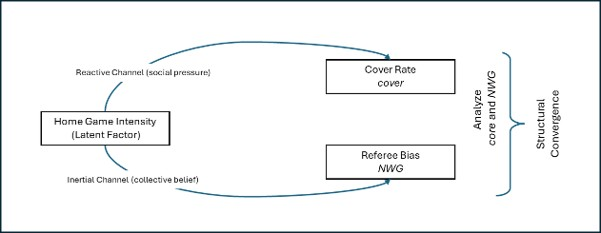  
*Fig. 1 — The Structural Convergence Framework*

### 3.2 Key Variables & Definitions

Before formalizing the hypotheses, we define the two primary metrics used throughout the analysis.

**Net Whistle Gain (NWG)** — the net difference between referee errors favouring the home team and referee errors favouring the away team in the final two minutes of a close game. A positive NWG indicates realized referee bias toward the home team. Formally:

$$\beta = |\{ \text{INC} : \text{committing\_side} = \text{home} \}| + |\{ \text{IC} : \text{disadvantaged\_side} = \text{home} \}|$$

$$\delta = |\{ \text{INC} : \text{disadvantaged\_side} = \text{home} \}| + |\{ \text{IC} : \text{committing\_side} = \text{home} \}|$$

$$NWG = \beta - \delta$$

**Cover Rate** — a binary outcome indicating whether the home team beat the point spread set by bookmakers before the game:

$$\text{cover} = \begin{cases} 1 & \text{if home team beat the spread} \\ 0 & \text{if home team did not beat the spread} \\ \text{excluded} & \text{if margin} = \text{spread (push)} \end{cases}$$
### 3.3 Formal Statistical Framework

#### 3.3.1 RQ1 — The Reactive Channel

Does home-court referee bias exist in the data, and does it vary with crowd presence? Following Pelechrinis (2023) [PelechrinisL2M], we adopt a one-tailed test:

$$H_0^{RQ1}: E[NWG] \leq 0 \quad \text{(no systematic home-court referee bias)}$$

$$H_1^{RQ1}: E[NWG] > 0 \quad \text{(referee errors systematically favour the home team)}$$

The empirical p-value is defined as:

$$p = \frac{|\{t_{sim} \geq t_{real}\}|}{n_{sim}}$$

where $t_{real}$ is the observed sum of NWG and $t_{sim}$ is the simulated sum under $H_0^{RQ1}$, generated via Monte Carlo simulation following Pelechrinis (2023) [PelechrinisCode]. The test is conducted across three periods defined by crowd presence conditions:

- **Pre-COVID** (2015–2019): Full capacity arenas.
- **COVID** (2020–2022): Restricted or no attendance — natural experiment.
- **Post-COVID** (2023–2025): Full capacity arenas restored.

#### 3.3.2 RQ2 — The Inertial Channel

Does the betting market systematically misprice home-court advantage in close games? Throughout this study, *cover* refers exclusively to the home team covering the spread (see Glossary, Section 3.6). We adopt a two-sided test:

$$H_0^{RQ2}: P(\text{home\_cover}) = 0.50 \quad \text{(the market efficiently prices home-court advantage)}$$

$$H_1^{RQ2}: P(\text{home\_cover}) \neq 0.50 \quad \text{(the market systematically misprices home-court advantage)}$$

The test is conducted via a two-sided binomial test across the same three temporal periods.


### 3.4 Variables

For each game we measure the following variables.

**$\beta$ and $\delta$** — defined in Section 3.2. Measured at the play level as the count of referee errors favouring the home team and the away team respectively.

**$NWG$** — defined in Section 3.2, the primary test statistic for $H_0^{RQ1}$ in Section 3.3.1. Grouped into three categories for exploratory analysis: $NWG < 0$ (away bias), $NWG = 0$ (no bias), $NWG > 0$ (home bias).

**$AR$** — defined in Section 3.2, an alternative expression of $NWG$ as a proportion. Undefined when $\beta + \delta = 0$.

**Point spread** — pre-game market expectation of the home team's margin, used in the construction of the cover outcome variable.

**Cover outcome** — the primary test statistic for $H_0^{RQ2}$ in Section 3.3.2.

**Control variables** — season, temporal period (Pre-COVID / COVID / Post-COVID), playoff status, and attendance as a proxy for crowd pressure.

### 3.5 Assumptions

1. L2M grades are treated as ground truth for referee error classification.
2. Errors are independent across plays within a game.
3. The three periods (Pre-COVID, COVID, Post-COVID) are structurally distinct with respect to crowd presence conditions — this assumption is tested empirically in Section 7.2.
4. Betting lines are set before the game with no access to L2M data — bookmakers cannot observe referee errors at the time of line setting.
5. CNC decisions are excluded — their grading criteria changed across seasons [PelechrinisL2M].
6. This study does not test real-time market efficiency. $NWG$ is a post-game measure and cannot be used as a trading signal. Structural Convergence requires only that both signals consistently point in the same direction — not that one predicts the other.

All tests are conducted at $\alpha = 0.05$.

### 3.6 Glossary

**Point Spread** — Pre-game margin set by bookmakers. Example: Lakers −5.5 must win by 6+ points to cover.

**Cover** — A team covers when they beat the bookmaker's margin. Throughout this study, *cover* refers exclusively to the home team covering the spread. The favourite covers by winning by more than the spread; the underdog covers by losing by less (or winning outright). Pushes are excluded from all cover rate calculations.

**Push** — Final margin equals the spread exactly. No winner — stakes returned. Pushes are excluded from cover rate calculations.

**INC (Incorrect Non-Call)** — A violation occurred but was not called. Example: a clear push-off goes uncalled in the final minute.

**IC (Incorrect Call)** — A call was made but no violation occurred. Example: a foul is called on a defender who did not make contact.

**L2M Report** — Official NBA post-game grading of every referee decision in the final two minutes of close games. Published since March 2015.

**NWG (Net Whistle Gain)** — Net referee errors favouring the home team. Positive = home bias; negative = away bias; zero = no bias. Formally defined in Section 3.2.

**AR (Asymmetry Ratio)** — NWG expressed as a proportion. $AR = 0.5$ indicates no bias; $AR > 0.5$ indicates home bias; $AR < 0.5$ indicates away bias. Undefined when $\beta + \delta = 0$. Formally defined in Section 3.2.

**Market Mispricing** — The systematic deviation of the home team cover rate from 50% in close games, as tested via $H_0^{RQ2}$.

**Structural Convergence** — The hypothesis that RQ1 and RQ2 consistently point in the same direction — without requiring a causal link between them.

## 4. Data availibility

### 4.1. Initial Data Analysis (IDA)

#### 4.1.1 NBA Last Two Minute Reports (Primary Dataset)

The primary dataset is the NBA Last Two Minute (L2M) reports, maintained by atlhawksfanatic [AtlhawksfanaticL2M]. A Last Two Minute Report, or “L2M,” is a play-by-play report regarding all calls and material non-calls in the last two minutes of the fourth quarter or the last two minutes of any overtime period (if applicable) for all games (including playoffs) that meet designated criteria. This dataset is selected for three reasons. First, it provides ground truth — every referee decision in the final two minutes of close games is independently graded as correct or incorrect by the NBA league office, which is rare in sports officiating research. Second, it is the same dataset used by Pelechrinis (2023) [PelechrinisL2M], allowing direct replication and comparison of results. Third, it covers seasons 2015–2025, which includes the COVID-19 period during which games were played without fans — a natural comparison condition for examining the role of crowd presence in referee decision-making.

The reports are released by the NBA for games that were within 5 points in the last two minutes. The dataset is compiled from two sources: archived PDF reports for earlier seasons and the official NBA API for more recent ones. It is supplemented with box score data from stats.nba.com, which adds referee identities, attendance, and player minutes [AtlhawksfanaticL2M]. The dataset is the primary source used in Pelechrinis (2023) [PelechrinisL2M], as confirmed by the accompanying code repository [PelechrinisCode].



In [3]:
nba_data = pd.read_csv('data/input/L2M_stats_nba.zip', low_memory=False)

print(nba_data.head(10))
print()
print(nba_data.columns.tolist())

  period     time                       call_type        committing  \
0     Q4  01:52.0                  Foul: Shooting        Josh Smith   
1     Q4  01:43.0                  Foul: Shooting          JR Smith   
2     Q4  01:32.0                  Foul: Shooting      Trevor Ariza   
3     Q4  01:09.0                Foul: Loose Ball    Terrence Jones   
4     Q4  00:53.0                  Foul: Shooting  Tristan Thompson   
5     Q4  00:29.1                  Foul: Shooting    Terrence Jones   
6     Q5  04:34.0                  Foul: Shooting  Tristan Thompson   
7     Q5  04:34.0  Instant Replay: Support Ruling               NaN   
8     Q5  04:05.0                  Foul: Personal      LeBron James   
9     Q5  03:54.0           Foul: Double Personal      LeBron James   

      disadvantaged decision  \
0        Kevin Love      CNC   
1      James Harden       CC   
2      LeBron James       CC   
3  Tristan Thompson       CC   
4        Josh Smith      CNC   
5      LeBron James      C

The full list of variables is describe into README.md file in  **[AtlhawksfanaticL2M]**
- time remaining in the period when play occurred
- call_type: raw call type variable in L2M
- committing: committing player or team of the graded infraction in L2M, may be blank
- disadvantaged: disadvantaged player or team of the graded infraction in L2M, may be blank
- decision: judgment of L2M for the call, could be CC, CNC, IC, INC, or blank where CC = Correct Call, CNC = Correct Non-Call, IC = Incorrect Call, INC = Incorrect Non-Call and blank = ot detectable without technology
- comments: L2M comments on the play
- game_details: game details of L2M, only relevant for PDFs
- page: page of L2M for pdf, not applicable for games accessed through API
- file: name of L2M file, will be the saved .csv file for API data
- game_date: game date according to L2M report header
- away_team: away team nickname
- home_team: home team nickname
- date: date of game in YYYY-MM-DD format
- call: first part of call_type, this is before the colon in call_type
- type: second part of call_type, this is after the colon in call_type
- home: home team abbreviation
- away: away team abbreviation
- gid: NBA game ID
- gcode: NBA game code
- home_score: home final score from the L2M reports, incomplete variable
- away_score: away final score from the L2M reports, incomplete variable
- national_tv: national TV network for the game, “no” indicates none
- networks: shorthand TV network for the game, NBALP indicates league pass
- game_id: nba.com url for L2M game, last part of “https://official.nba.com/l2m/L2MReport.html/”, not applicable for PDFs
- PCTime: from official API
- ImposibleIndicator: from official API
- Difficulty: from official API
- VideolLink: from official API
- Qualifier: from official API
- posID: from official API
- posStart: from official API
- posEnd: from official API
- posTeamId: from official API
- teamIdInFavor: from official API
- errorInFavor: from official API
- imgChart: from official API
- GameId: from official API
- GameDate: from official API
- HomeTeamId: from official API
- AwayTeamId: from official API
- L2M_Comments: from official API
- season: NBA season for which the graded play was a part of, convention is to use the last year of the NBA season so 2015 refers to the 2014-15 Season
- playoff: dummy variable equal to TRUE if the game occurred in the playoffs
- GAME_ID: NBA API game ID, same as gid
- OFFICIAL_1: name of first referee for game
- OFFICIAL_2: name of second referee for game
- OFFICIAL_3: name of third referee for game
- OFFICIAL_ID_1: ID of first referee for game
- OFFICIAL_ID_2: ID of second referee for game
- OFFICIAL_ID_3: ID of third referee for game
- OFFICIAL_4: name of fourth referee for game, typically only for playoff games
- OFFICIAL_ID_4: ID of fourth referee for game, typically only for playoff games
- ATTENDANCE: attendance for the game
- committing_min: total minutes played by player committing action (note, may be NA because the player did not play and likely an input error from NBA on L2M)
- committing_team: team for committing player
- committing_side: home/away for committing player
- disadvantaged_min: total minutes played by player disadvantaged by action
- disadvantaged_team: team for disadvantaged player
- disadvantaged_side: home/away for disadvantaged player
- type2: consistent format for type of infraction
- time_min: minutes remaining in period
- time_sec: seconds remaining in period
- time2: fractional minutes left (ie 1.9 would be one minute and 54 seconds)


In [4]:
pd.set_option('display.max_colwidth', None)
print(nba_data['comments'].head(10))
pd.reset_option('display.max_colwidth')

0                                                     Smith (HOU) does not make contact with Love (CLE) as he attempts the layup.
1                     Smith (CLE) makes contact with the body of Harden (HOU) and the contact affects his movement to the basket.
2                          Ariza (HOU) makes contact with the shoulder of James (CLE) while trying to strip the ball from behind.
3                            Jones (HOU) makes contact with the arm of Thompson (CLE) causing him to lose control of the rebound.
4                                                             Smith (HOU) loses the ball as he goes up for the shot in the paint.
5                                                                      Jones (HOU) maintains verticality on drive by James (CLE).
6                                           Thompson (CLE) makes contact to the head of Jones (HOU) from behind on the jump shot.
7        After communicating with the Replay Center, the foul was confirmed to have taken 

a) **Shape** — we check the number of rows and columns to confirm the dataset loaded correctly and matches the expected size from the source.

In [5]:
# Shape
print('Shape:', nba_data.shape)

Shape: (90302, 64)


The dataset contains 90,302 rows and 64 columns. Each row represents a single graded play — either a call made by referees or a potential violation that was not called. 
It is fully described in the README of [AtlhawksfanaticL2M]. Based on the source documentation, the following columns are identified as candidates for analysis.

`decision`, `committing_side`, and `disadvantaged_side` are the primary candidates for measuring directional bias, as they classify each play and identify which side was involved. `call_type` and `type2` are candidates for controlling violation difficulty, as they provide a consistent classification of infraction types across seasons. `season` and `playoff` are candidates for temporal segmentation, as they identify the competitive context of each game. `ATTENDANCE` is a candidate for measuring crowd presence, as it records the number of fans at each game. `national_tv` is a candidate for measuring visibility and popularity, as it identifies whether the game was nationally broadcast. `committing` and `disadvantaged` are candidates for player-level analysis, as they provide the names of players involved in each play. `home_score` and `away_score` are candidates for measuring in-game context, though the source documentation notes them as incomplete variables. `OFFICIAL_1`, `OFFICIAL_2`, and `OFFICIAL_3` are candidates for referee identification, as they provide crew composition per game.

b) **Data types** — we inspect the type of each column to identify parsing issues. Dates stored as strings or booleans stored as objects will need conversion before analysis.

In [46]:
key_cols = ['date', 'playoff', 'season', 'ATTENDANCE', 'decision', 
            'committing_side', 'disadvantaged_side', 'call_type',
            'period', 'time']
print(nba_data[key_cols].head())
print(nba_data[key_cols].dtypes)

         date  playoff  season  ATTENDANCE decision committing_side  \
0  2015-03-01    False    2015     18345.0      CNC            home   
1  2015-03-01    False    2015     18345.0       CC            away   
2  2015-03-01    False    2015     18345.0       CC            home   
3  2015-03-01    False    2015     18345.0       CC            home   
4  2015-03-01    False    2015     18345.0      CNC            away   

  disadvantaged_side         call_type period     time  
0               away    Foul: Shooting     Q4  01:52.0  
1               home    Foul: Shooting     Q4  01:43.0  
2               away    Foul: Shooting     Q4  01:32.0  
3               away  Foul: Loose Ball     Q4  01:09.0  
4               home    Foul: Shooting     Q4  00:53.0  
date                   object
playoff                  bool
season                  int64
ATTENDANCE            float64
decision               object
committing_side        object
disadvantaged_side     object
call_type            

> **Observation** — Key columns are inspected for parsing issues prior to analysis. The results show that `date` is stored as object (string) and requires conversion to datetime. All other key columns have the expected types: `playoff` is boolean, `season` and `ATTENDANCE` are numeric, and categorical columns (`decision`, `committing_side`, `disadvantaged_side`, `call_type`, `period`) are object, which is expected for string categories. The conversion of `date` will be performed in the Tidy Data Preparation section.

c) **Missing values** — we identify columns with missing data early. Some are expected — for example, `committing_min` is missing where the NBA made input errors. Others may signal structural issues in the data.

In [47]:
# Missing values
print('\nMissing values:')
print(nba_data.isnull().sum()[nba_data.isnull().sum() > 0])


Missing values:
call_type                48
committing             1522
disadvantaged          4983
decision               2502
comments                 59
game_details          58270
page                  58270
call                     48
type                     48
networks              88993
game_id               32032
PCTime                32032
ImposibleIndicator    32032
Difficulty            34148
VideolLink            32032
Qualifier             90302
posID                 32032
posStart              32032
posEnd                32032
posTeamId             32032
teamIdInFavor         90302
errorInFavor          90302
imgChart              32032
GameId                32032
GameDate              32032
HomeTeamId            32032
AwayTeamId            32032
L2M_Comments          89809
GAME_ID                 631
OFFICIAL_1              631
OFFICIAL_2              631
OFFICIAL_3              643
OFFICIAL_ID_1           631
OFFICIAL_ID_2           631
OFFICIAL_ID_3           643
OFF

Missing values fall into three categories.

* Expected and structural: `game_details` and `page` have 58,270 missing values each — these come from the PDF pipeline and are absent for all API-sourced games. `networks`, `L2M_Comments`, `Qualifier`, `teamIdInFavor`, and `errorInFavor` are largely or entirely missing and are not used in the analysis. `OFFICIAL_4` and `OFFICIAL_ID_4` have 88,203 missing values — a fourth referee appears only in some playoff games.

* Require attention: `decision` has 2,502 missing values — these are blank entries representing plays not detectable without technology and are excluded from analysis. `committing_side` and `disadvantaged_side` have 2,433 and 5,801 missing values respectively — these are critical for home/away bias calculation and will be examined in the Tidy Data Preparation section. `OFFICIAL_1`, `OFFICIAL_2`, and `OFFICIAL_3` have 631, 631, and 643 missing values respectively — games without referee data cannot be included in referee crew analysis. `ATTENDANCE` has 6,509 missing values, which affects crowd pressure analysis.

* Known data quality issue: `committing_min` has 3,183 missing values due to NBA input errors where the player did not actually play, documented separately in `no_minutes.csv` [AtlhawksfanaticL2M].

Missing values fall into three categories: structural (expected from the two-source pipeline), known data quality issues (documented in `no_minutes.csv`), and gaps in key analysis columns (`decision`, `committing_side`, `OFFICIAL_1/2/3`) that will be quantified in the Tidy Data Preparation section.

> **Observation** — Missing values fall into three categories: structural (expected from the two-source pipeline), known data quality issues, and gaps in key analysis columns (`decision`, `committing_side`, `OFFICIAL_1/2/3`) that will be quantified in the Tidy Data Preparation section.

**Dublication values** -we check whether the dataset contains any exact duplicate rows.

In [8]:
print('Duplicate rows:', nba_data.duplicated().sum())

Duplicate rows: 13


13 duplicate rows found — each is an exact copy of another row.
We inspect which games and decisions are affected.

In [9]:
print(nba_data[nba_data.duplicated(keep=False)][['season', 'home_team', 'away_team', 'date', 'decision', 'call_type', 'ATTENDANCE']].sort_values('date'))

       season  home_team      away_team        date decision  \
3392     2016      Bucks  Trail Blazers  2015-12-07      INC   
3393     2016      Bucks  Trail Blazers  2015-12-07      INC   
3414     2016       Heat        Wizards  2015-12-07       CC   
3415     2016       Heat        Wizards  2015-12-07       CC   
7730     2016      Hawks      Cavaliers  2016-04-01       CC   
7731     2016      Hawks      Cavaliers  2016-04-01       CC   
10711    2017      Bucks          Hawks  2016-12-09      CNC   
10712    2017      Bucks          Hawks  2016-12-09      CNC   
10913    2017      Bulls   Timberwolves  2016-12-13       CC   
10914    2017      Bulls   Timberwolves  2016-12-13       CC   
13548    2017      Bulls        Raptors  2017-02-14       CC   
13549    2017      Bulls        Raptors  2017-02-14       CC   
35552    2019  Grizzlies          Magic  2019-03-10       CC   
35551    2019  Grizzlies          Magic  2019-03-10       CC   
49663    2021   Warriors           Heat 

In [10]:
dupes = nba_data[nba_data.duplicated(keep=False)]
print('Total duplicate rows:', len(dupes))
print('Rows where all columns are identical to another row:')
print(nba_data.duplicated(keep='first').sum())

Total duplicate rows: 26
Rows where all columns are identical to another row:
13


26 rows are shown because `keep=False` marks both the original and the copy. Each pair represents one duplicate — 13 pairs total.

We check how many unique games are affected.

In [11]:
print(nba_data[nba_data.duplicated(keep=False)]['gid'].unique())

[21500310 21500306 21501131 21600340 21600370 21600831 21800996 22000443
 22000459 22100105 22100852 22400587 22400931]


> **Observation** — the dataset contains 13 duplicate rows. `duplicated(keep='first')` returns 13 — the number of rows to be removed. `duplicated(keep=False)` returns 26 — both the original and the copy in each pair. The duplicates span 13 different games across seasons 2016–2025, confirmed by 13 unique `gid` values. Each game has exactly one duplicated row — a double entry from the parsing pipeline.

##### **COLUMN-LEVEL ANALYSIS** 

- **Decision column** — the core variable of the analysis. We examine the distribution of values to understand the balance between correct and incorrect calls, and to confirm the presence of blank entries that will be excluded.  CC (Correct Call), CNC (Correct Non-Call), IC (Incorrect Call), and INC (Incorrect Non-Call)

In [12]:
print(nba_data['decision'].value_counts(dropna=False))

decision
CNC    60590
CC     21023
INC     5391
NaN     2502
IC       796
Name: count, dtype: int64


The key variable is `decision`, which takes four values: **CC** (Correct Call), **CN**C (Correct Non-Call), **IC** (Incorrect Call), and **INC** (Incorrect Non-Call). A fifth value — blank — indicates plays that were not detectable without technology and are excluded from analysis.

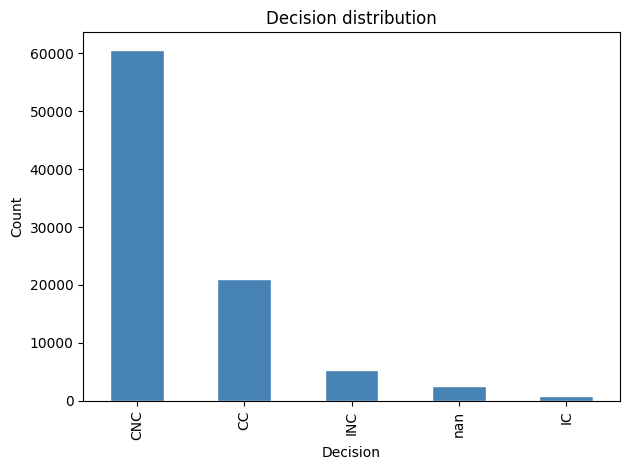

In [13]:
nba_data['decision'].value_counts(dropna=False).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Decision distribution')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The `decision` column is the core variable of the analysis. It takes four values: CC (Correct Call), CNC (Correct Non-Call), IC (Incorrect Call), and INC (Incorrect Non-Call). A fifth value — blank (NaN) — indicates plays not detectable without technology.

The distribution shows that CNC dominates with 60,590 entries (67.2% of all rows), followed by CC (21,023), INC (5,391), NaN (2,502), and IC (796). Pelechrinis (2023) notes that CNC criteria changed across seasons — during the 2015 season there were 6.4 CNC entries per game, while during the 2022 season there were almost 14 [PelechrinisL2M]. This inconsistency makes CNC unsuitable for longitudinal analysis. NaN entries are also excluded as they represent plays not detectable without technology. The working dataset therefore consists of CC (21,023), IC (796), and INC (5,391) — a total of 27,210 rows.

- **Season column** — we check the distribution of rows by season to confirm coverage and identify any gaps.

We count the number of rows per season to confirm coverage and identify gaps.

In [14]:
# Games per season
print(nba_data.groupby('season')['gid'].nunique())

season
2015    139
2016    439
2017    428
2018    475
2019    455
2020    395
2021    406
2022    442
2023    474
2024    411
2025    423
Name: gid, dtype: int64


2018 has more games (475) than 2019 (455), yet 2019 has more rows. This means the difference is not in the number of games — we check average actions per game to find the cause.

**Note** — the dataset contains 395–475 games per season, not 1,230. L2M reports are released only for close games (≤5 points in the last two minutes), which represents approximately 35–40% of all regular season games. A standard NBA season has 1,230 games (30 teams × 82 games / 2) [AtlhawksfanaticL2M].

In [15]:
# Rows per game by season
print(nba_data.groupby('season').apply(
    lambda x: len(x) / x['gid'].nunique(), include_groups=False
).round(1))

season
2015    14.2
2016    15.6
2017    17.6
2018    22.3
2019    25.1
2020    20.8
2021    19.5
2022    20.0
2023    24.3
2024    20.1
2025    16.9
dtype: float64


2019 peaks at 25.1 actions per game — the highest in the dataset. This confirms that 2019 has more rows than 2018 despite fewer games because referees reviewed more actions per game. The drop in 2020–2022 reflects both fewer games (395–406 vs 455–475) and fewer actions per game (19.5–20.8 vs 25.1).

**Note** — A standard NBA season has 1,230 games (30 teams × 82 games / 2) [FansidedNBA]

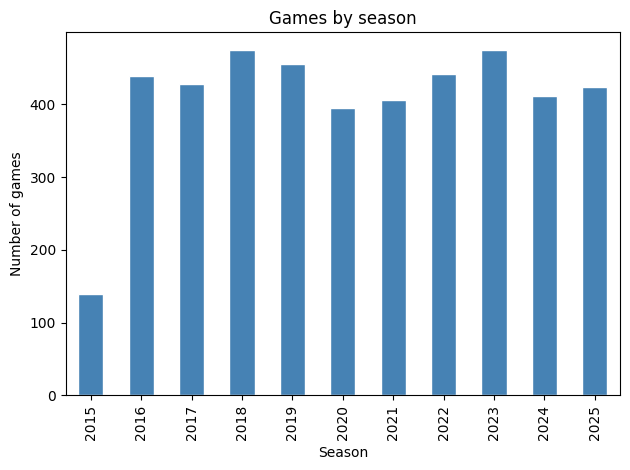

In [16]:
nba_data.groupby('season')['gid'].nunique().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Games by season')
plt.xlabel('Season')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

> **Observation** — 2015 has significantly fewer rows (1,972) and fewer games (139) as it was the first year of L2M reporting. Coverage stabilizes from 2016 onward. The drop in 2020–2022 reflects both fewer games (395–442 vs 455–475 in 2018–2019) and fewer graded actions per game (19.5–20.8 vs 25.1 in 2019). 2025 shows the lowest actions per game (16.9) because the season was still ongoing when the data was collected.

- **Playoff column** — We check the split between regular season and playoff games.

In [17]:
print('Unique values:')
print(nba_data['playoff'].unique())
print()
print('Missing:', nba_data['playoff'].isnull().sum())
print()
print(nba_data['playoff'].value_counts())

Unique values:
[False  True]

Missing: 0

playoff
False    83721
True      6581
Name: count, dtype: int64


> **Observation** — no missing values. Two clean boolean values. 6,581 rows (7.3%) are playoff games. Playoff games will be analyzed separately as [PelechrinisL2M] found home court bias to be more pronounced in the playoffs.

- **Committing side** - `committing_side` — identifies whether the player committing the infraction belongs to the home or away team. Together with `decision`, this is the core column for calculating home/away bias. A systematic imbalance — where home teams commit more unpenalized infractions — would indicate referee bias in favor of the home team.

In [18]:
print('Unique values:')
print(nba_data['committing_side'].unique())
print()
print('Missing:', nba_data['committing_side'].isnull().sum())
print()
print(nba_data['committing_side'].value_counts(dropna=False))

Unique values:
['home' 'away' nan]

Missing: 2433

committing_side
away    44183
home    43686
NaN      2433
Name: count, dtype: int64


> **Observation** — The `committing_side` column identifies whether the player committing the infraction belongs to the home or away team. Together with `decision`, it is the core column for calculating β and δ as defined in Section 3.1. The column takes two clean values: `home` and `away`, with 2,433 missing values (2.7%). The distribution is nearly balanced — 44,183 away (49.9%) and 43,686 home (49.4%) — which is expected as there is no a priori reason for one side to commit more infractions. Missing values will be examined in the Tidy Data Preparation section.

- **Disadvantaged side** -`disadvantaged_side` — identifies whether the player disadvantaged by the infraction belongs to the home or away team. Used together with `committing_side` and `decision` to determine the direction of benefit from each error.

In [19]:
print('Unique values:')
print(nba_data['disadvantaged_side'].unique())
print()
print('Missing:', nba_data['disadvantaged_side'].isnull().sum())
print()
print(nba_data['disadvantaged_side'].value_counts(dropna=False))

Unique values:
['away' 'home' nan]

Missing: 5801

disadvantaged_side
home    42428
away    42073
NaN      5801
Name: count, dtype: int64


> **Observation** — The `disadvantaged_side` column identifies whether the player disadvantaged by the infraction belongs to the home or away team. Together with `committing_side` and `decision`, it determines the direction of benefit from each referee error. The column takes two clean values: `home` and `away`, with 5,801 missing values (6.4%) — notably more than `committing_side` (2,433). The distribution is nearly balanced — 42,428 home (47.0%) and 42,073 away (46.6%). The higher missing rate is expected, as some plays have a committing player but no clearly identified disadvantaged player. Missing values will be examined in the Tidy Data Preparation section.

* **Attendance field** `ATTENDANCE` — used as a proxy for crowd pressure. We check the range and distribution of values, including games with zero attendance which correspond to the COVID bubble.

Unique values and missing — we check the range of attendance values and identify missing entries.

In [20]:
print('Unique values:')
print(nba_data['ATTENDANCE'].unique())
print()
print('Missing:', nba_data['ATTENDANCE'].isnull().sum())
print()
print(nba_data['ATTENDANCE'].value_counts(dropna=False))

Unique values:
[18345. 18624. 13109. ... 19734. 19932. 17561.]

Missing: 6509

ATTENDANCE
NaN        6509
18997.0    2345
19800.0    2119
19600.0    1968
19812.0    1752
           ... 
21749.0       4
18434.0       4
14629.0       4
17831.0       2
15393.0       1
Name: count, Length: 2176, dtype: int64


Distribution plot — we visualize the attendance distribution to identify patterns and anomalies.

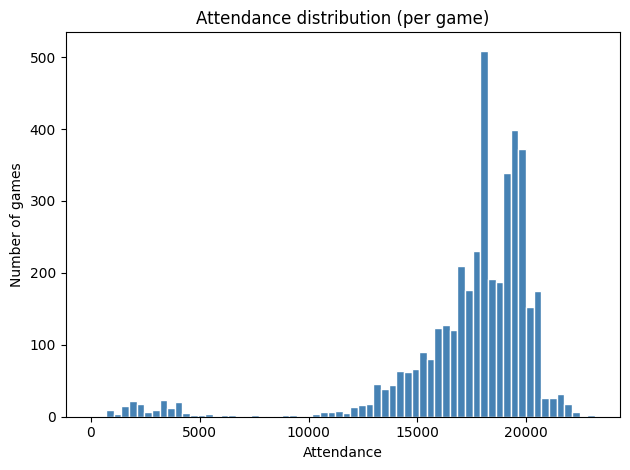

In [21]:
nba_data.drop_duplicates(subset='gid')['ATTENDANCE'].dropna().plot(
    kind='hist', bins='fd', color='steelblue', edgecolor='white')
plt.title('Attendance distribution (per game)')
plt.xlabel('Attendance')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

Low attendance investigation — the histogram shows a small group below 5,000. We identify which seasons these belong to.

In [22]:
print('Rows with ATTENDANCE < 5000:')
print(nba_data[nba_data['ATTENDANCE'] < 5000]['season'].value_counts().sort_index())

Rows with ATTENDANCE < 5000:
season
2021    2864
2022      13
Name: count, dtype: int64


**Unexpected finding** — zero attendance appears only in 2022, not in 2020 as expected from the COVID bubble. We investigate which games these are. 2022 low attendance

In [23]:
mask = (nba_data['ATTENDANCE'] < 5000) & (nba_data['season'] == 2022)
cols = ['gid', 'season', 'home_team', 'away_team', 'date', 'call_type', 'decision', 'ATTENDANCE']
print(f'Rows: {mask.sum()}, Unique games: {nba_data[mask]["gid"].nunique()}')
print(nba_data[mask][cols].to_string())

Rows: 13, Unique games: 1
            gid  season home_team away_team        date               call_type decision  ATTENDANCE
59965  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Personal      CNC         0.0
59966  22100850    2022   Raptors   Nuggets  2022-02-12         Foul: Offensive      CNC         0.0
59967  22100850    2022   Raptors   Nuggets  2022-02-12         Foul: Offensive      CNC         0.0
59968  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting      CNC         0.0
59969  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting       CC         0.0
59970  22100850    2022   Raptors   Nuggets  2022-02-12  Foul: Defense 3 Second      INC         0.0
59971  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting      CNC         0.0
59972  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Personal      CNC         0.0
59973  22100850    2022   Raptors   Nuggets  2022-02-12          

We confirm the single 2022 game with restricted attendance and verify that 13 rows correspond to one game.

In [24]:
games = nba_data.drop_duplicates(subset='gid')
print(games.groupby('home_team')['ATTENDANCE'].median().sort_values(ascending=False).head(15))

home_team
Bulls            21116.0
76ers            20319.5
Mavericks        20157.0
Knicks           19812.0
Raptors          19800.0
Heat             19600.0
Nuggets          19520.0
Cavaliers        19432.0
Trail Blazers    19393.0
Clippers         19060.0
Lakers           18997.0
Celtics          18624.0
Spurs            18354.0
Jazz             18306.0
Thunder          18203.0
Name: ATTENDANCE, dtype: float64


Тhe peaks in the attendance distribution reflect fixed arena capacities. Bulls lead with median 21,116, followed by 76ers (20,319) and Mavericks (20,157). This is expected — arenas have a maximum capacity which creates natural clustering. This does not affect our analysis.

In [42]:
def calc_entropy(series):
    counts = pd.cut(series, bins=20).value_counts()
    probs = counts / counts.sum()
    return entropy(probs)

attendance_entropy = nba_data.drop_duplicates(subset='gid').groupby('season')['ATTENDANCE'].apply(
    lambda x: calc_entropy(x.dropna())
)

print(attendance_entropy)

season
2015    2.615408
2016    2.527409
2017    2.599285
2018    2.492446
2019    2.492698
2020    2.613304
2021    2.075035
2022    2.129570
2023    2.453236
2024    2.387664
2025    2.290795
Name: ATTENDANCE, dtype: float64


Pre-COVID seasons (2015–2020) show stable entropy between 2.49 and 2.61, reflecting the natural variation of normal game attendance. The COVID seasons (2021–2022) show a sharp drop to 2.07–2.13, consistent with restricted capacity games clustering around a narrow range of low values. Post-COVID seasons (2023–2025) show partial recovery to 2.29–2.45, but have not returned to Pre-COVID levels. 

The entropy pattern suggests that `ATTENDANCE` may be more appropriately treated as a categorical variable than a continuous one, as it reflects arena capacity constraints and a structural break during the COVID period. This will be considered in the Tidy Data Preparation section.

> **Observation** — The `ATTENDANCE` column records the number of fans present at each game and is used as a proxy for crowd pressure. It has 6,509 missing values (7.2%). The distribution clusters between 13,000–23,000, reflecting fixed arena capacities. Bulls lead with a median of 21,116, followed by 76ers (20,319) and Mavericks (20,157). A secondary cluster of 2,877 rows falls below 5,000 — 2,864 from the 2021 season played with restricted crowd capacity due to the COVID-19 pandemic, and 13 rows from a single Raptors vs Nuggets game (February 12, 2022) played without fans due to local public health restrictions. When analyzing the relationship between attendance and referee bias, the low-attendance group must be treated separately or controlled for via the `season` variable.

* **Call type** — we check the distribution of violation types to understand what kinds of plays are graded in the L2M reports.

In [48]:
print(nba_data['call_type'].value_counts().head(10))

call_type
Foul: Personal                    27223
Foul: Shooting                    23121
Foul: Offensive                   17318
Foul: Loose Ball                   8303
Turnover: Traveling                3224
Foul: Defense 3 Second             1360
Stoppage: Out-of-Bounds            1092
Instant Replay: Support Ruling      905
Foul: Personal Take                 775
Turnover: 3 Second Violation        704
Name: count, dtype: int64


> **Observation** — The `call_type` column identifies the type of infraction graded in each L2M report. The distribution is heavily skewed toward foul calls — personal fouls (27,223) and shooting fouls (23,121) together account for more than half of all graded plays. Offensive fouls (17,318) and loose-ball fouls (8,303) follow. Non-foul infractions such as travelling violations (3,224) and out-of-bounds stoppages (1,092) are less frequent. This distribution is relevant for the Monte Carlo simulation (Section 3.2), which estimates base error rates separately for each violation type. The dominance of foul calls means that the simulation is primarily driven by foul-related base rates. Fouls are also the most subjective call type — referee discretion is highest in foul situations — making them the most likely category to exhibit systematic bias. The `call_type` column is used exclusively in the Monte Carlo simulation to estimate violation-specific base error rates, as described in Section 3.2.

* **Period and time** — we check which periods are covered and the time range within each period.

In [49]:
print('Period distribution:')
print(nba_data['period'].value_counts())

Period distribution:
period
Q4    78374
Q5    10533
Q6     1189
Q7      129
Q8       77
Name: count, dtype: int64


> **Observation** — The `period` column identifies the game period of each graded play. The majority of plays occur in Q4 (78,374, 86.8%). Overtime periods Q5 through Q8 account for 11,928 rows (13.2%), distributed across Q5 (10,533), Q6 (1,189), Q7 (129), and Q8 (77). Overtime games are included in the analysis as they represent close game situations where crowd pressure and referee bias are equally relevant.

* **Time remaining** — we check the range of time values within periods.

In [50]:
print(nba_data['time_min'].describe())

count    90302.000000
mean         0.435029
std          0.575313
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         12.000000
Name: time_min, dtype: float64


`time_min` max of 12 is unexpected. L2M reports should only cover the last two minutes of each period. We investigate these rows.

In [51]:
print(nba_data[nba_data['time_min'] > 2][['period', 'time', 'time_min', 'season', 'decision']].head(10))

    period     time  time_min  season decision
6       Q5  04:34.0         4    2015       CC
7       Q5  04:34.0         4    2015       CC
8       Q5  04:05.0         4    2015      CNC
9       Q5  03:54.0         3    2015      INC
134     Q5  04:50.0         4    2015      CNC
135     Q5  04:42.0         4    2015       CC
136     Q5  04:26.0         4    2015      CNC
137     Q5  04:02.0         4    2015       CC
138     Q5  03:43.0         3    2015       CC
139     Q5  03:41.0         3    2015      CNC


Rows with `time_min > 2` are exclusively from Q5 (overtime) in the 2015 season. In overtime, the full 5-minute period was graded, not just the last 2 minutes. This is a known inconsistency in early L2M reporting. These rows are outside the standard 2-minute window but will be retained — excluding them would disproportionately affect 2015 data, which is already the smallest season.

> **Observation** — The `time_min` column records the minutes remaining in the period. The median is 0 and the 75th percentile is 1 minute, confirming that most graded plays occur in the final minute of the period as expected for L2M reports. The maximum value of 12 minutes is unexpected — L2M reports should only cover the last two minutes of each period. Investigation shows that rows with `time_min > 2` are exclusively from overtime periods (Q5) in the 2015 season, where the full 5-minute overtime period was graded rather than only the last two minutes. This is a known inconsistency in early L2M reporting. These rows are retained in the analysis — excluding them would disproportionately reduce the already smallest season in the dataset (2015).

### 4.2 Exploratory Data Analysis (EDA)

## 6. Limitations

Several limitations should be considered when interpreting the results.

The L2M dataset covers only close games — games within 5 points in the last two minutes. This introduces a selection bias: the sample is not representative of all NBA games, and findings may not generalize to non-close games.

The Monte Carlo simulation uses 10,000 runs, which produces stable empirical p-values for moderate effect sizes but may underestimate significance for very large effects (reporting p < 0.001 rather than exact values).

Multiple hypothesis tests are conducted without Bonferroni correction, following Pelechrinis (2023) [PelechrinisL2M], which increases the risk of Type I error inflation.

The COVID period (2021–2022) conflates two potentially distinct conditions — games with zero attendance and games with restricted capacity. These are treated as a single period for simplicity.

SRS from Basketball Reference is a season-level measure and does not capture within-season variation in team strength, unlike the game-level ELO ratings.

Player and referee names were excluded from the dataset on ethical grounds. As a result, player-level bias analysis relies on career-level PER groupings rather than individual identification, which limits the granularity of the findings.

## Reference

[PelechrinisL2M] Pelechrinis, K. (2023). Quantifying implicit biases in refereeing using NBA referees as a testbed. *Scientific Reports*, 13, 4664. https://doi.org/10.1038/s41598-023-31799-y  
[PelechrinisCode] Pelechrinis, K. (2023). NBA-ref-analysis. GitHub. https://github.com/kpelechrinis/NBA-ref-analysis  
[AtlhawksfanaticL2M] atlhawksfanatic. (2025). L2M: NBA Last Two Minute Reports. GitHub. https://github.com/atlhawksfanatic/L2M  
[FansidedNBA] FanSided. (2024). How many games are in the NBA season? https://fansided.com/posts/how-many-games-are-in-the-nba-season-01j8kcxt31rr  
[ErikstadJohansen2020] Erikstad, M. K., & Johansen, B. T. (2020). Referee bias in professional football: Favoritism toward successful teams in potential penalty situations. Frontiers in Sports and Active Living, 2, 19. https://doi.org/10.3389/fspor.2020.00019  
[Barrett2021] Barrett, D. (2021). Star player bias in the NBA: A quantile regression approach. Empirical Economics Bulletin, 14(1), 9. 
[Rothman1990] Rothman, K. J. (1990). No adjustments are needed for multiple  comparisons. Epidemiology, 1(1), 43–46. https://doi.org/10.1097/00001648-199001000-00010


